In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:
# Load datasets
train = pd.read_csv('/content/sample_data/Train.csv')
var_defn = pd.read_csv('/content/sample_data/VariableDefinitions.csv')

# shape of the datasets
train.shape

(4809, 23)

- Train set has 4809 samples and 23 columns
- Test set has 1601 samples and 22 columns (without target column)

# Understanding Tourism Data

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4809 non-null   object 
 1   country                4809 non-null   object 
 2   age_group              4809 non-null   object 
 3   travel_with            3695 non-null   object 
 4   total_female           4806 non-null   float64
 5   total_male             4804 non-null   float64
 6   purpose                4809 non-null   object 
 7   main_activity          4809 non-null   object 
 8   info_source            4809 non-null   object 
 9   tour_arrangement       4809 non-null   object 
 10  package_transport_int  4809 non-null   object 
 11  package_accomodation   4809 non-null   object 
 12  package_food           4809 non-null   object 
 13  package_transport_tz   4809 non-null   object 
 14  package_sightseeing    4809 non-null   object 
 15  pack

- The tourism dataset contains more object/string columns (18 columns) than numerical columns (5 columns).
- There are also missing values in four columns: *travel_with*, *total_female*, *total_male*, and *most_impressing*, as their count values are lower than the total number of records in the training set.

In [4]:
# Columns
train.columns

Index(['ID', 'country', 'age_group', 'travel_with', 'total_female',
       'total_male', 'purpose', 'main_activity', 'info_source',
       'tour_arrangement', 'package_transport_int', 'package_accomodation',
       'package_food', 'package_transport_tz', 'package_sightseeing',
       'package_guided_tour', 'package_insurance', 'night_mainland',
       'night_zanzibar', 'payment_mode', 'first_trip_tz', 'most_impressing',
       'total_cost'],
      dtype='object')

In [5]:
# Columns description
# First way -> display(var_defn)

# Second way -> by using pandas
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
display(var_defn)

,Column Name,Definition
0,id,Unique identifier for each tourist
1,country,The country a tourist coming from.
2,age_group,The age group of a tourist.
3,travel_with,The relation of people a tourist travel with to Tanzania
4,total_female,Total number of females
5,total_male,Total number of males
6,purpose,The purpose of visiting Tanzania
7,main_activity,The main activity of tourism in Tanzania
8,infor_source,The source of information about tourism in Tanzania
9,tour_arrangment,The arrangment of visiting Tanzania


In [6]:
# Descriptive Statistical analysis
train.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,4809,4809,tour_999,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,4809,105,UNITED STATES OF AMERICA,695,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_group,4809,4,25-44,2487,NaN,NaN,NaN,NaN,NaN,NaN,NaN
travel_with,3695,5,Alone,1265,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_female,4806.0,NaN,NaN,NaN,0.926758,1.288242,0.0,0.0,1.0,1.0,49.0
total_male,4804.0,NaN,NaN,NaN,1.009575,1.138865,0.0,1.0,1.0,1.0,44.0
purpose,4809,7,Leisure and Holidays,2840,NaN,NaN,NaN,NaN,NaN,NaN,NaN
main_activity,4809,9,Wildlife tourism,2259,NaN,NaN,NaN,NaN,NaN,NaN,NaN
info_source,4809,8,"Travel, agent, tour operator",1913,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tour_arrangement,4809,2,Independent,2570,NaN,NaN,NaN,NaN,NaN,NaN,NaN


From the statistical summary above, we can deduce the following insights:

- The training data shows that the most common travelling age group is 25 to 44.
- Most people travel alone for leisure and holidays.
- Most travellers are from the United States of America.
- The training data indicates that wildlife tourism is the main activity, implying that most travellers spend more nights on the mainland compared to Zanzibar.
- Cash is the most commonly used mode of payment for tourism.

In [7]:
# Data structure of train set (first 8 rows)
train.head(8)

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost
0,tour_0,SWIZERLAND,45-64,Friends/Relatives,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Independent,...,No,No,No,No,13.0,0.0,Cash,No,Friendly People,674602.5
1,tour_10,UNITED KINGDOM,25-44,NaN,1.0,0.0,Leisure and Holidays,Cultural tourism,others,Independent,...,No,No,No,No,14.0,7.0,Cash,Yes,"Wonderful Country, Landscape, Nature",3214906.5
2,tour_1000,UNITED KINGDOM,25-44,Alone,0.0,1.0,Visiting Friends and Relatives,Cultural tourism,"Friends, relatives",Independent,...,No,No,No,No,1.0,31.0,Cash,No,Excellent Experience,3315000.0
3,tour_1002,UNITED KINGDOM,25-44,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,Yes,Yes,Yes,No,11.0,0.0,Cash,Yes,Friendly People,7790250.0
4,tour_1004,CHINA,1-24,NaN,1.0,0.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Independent,...,No,No,No,No,7.0,4.0,Cash,Yes,No comments,1657500.0
5,tour_1005,UNITED KINGDOM,25-44,NaN,0.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,No,Yes,Yes,No,9.0,3.0,Cash,Yes,Wildlife,120950.0
6,tour_1007,SOUTH AFRICA,45-64,Alone,0.0,1.0,Business,Mountain climbing,"Friends, relatives",Independent,...,No,No,No,No,9.0,0.0,Cash,Yes,Friendly People,466140.0
7,tour_1008,UNITED STATES OF AMERICA,45-64,Friends/Relatives,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,Yes,Yes,Yes,Yes,10.0,3.0,Cash,Yes,Friendly People,3480750.0


In [8]:
# Data structure of train set (last 8 rows)
train.tail(8)

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost
4801,tour_989,ITALY,45-64,Friends/Relatives,1.0,1.0,Meetings and Conference,Mountain climbing,"Newspaper, magazines,brochures",Independent,...,No,No,No,No,5.0,0.0,Cash,Yes,"Wonderful Country, Landscape, Nature",2269330.0
4802,tour_99,KENYA,45-64,Friends/Relatives,2.0,2.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Independent,...,No,No,No,No,10.0,5.0,Cash,Yes,No comments,6464250.0
4803,tour_991,GERMANY,1-24,Friends/Relatives,2.0,0.0,Leisure and Holidays,Beach tourism,"Newspaper, magazines,brochures",Independent,...,No,No,No,No,12.0,7.0,Cash,Yes,No comments,331500.0
4804,tour_993,UAE,45-64,Alone,0.0,1.0,Business,Hunting tourism,"Friends, relatives",Independent,...,No,No,No,No,2.0,0.0,Credit Card,No,No comments,3315000.0
4805,tour_994,UNITED STATES OF AMERICA,25-44,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,Yes,Yes,Yes,Yes,11.0,0.0,Cash,Yes,Friendly People,10690875.0
4806,tour_995,NETHERLANDS,1-24,NaN,1.0,0.0,Leisure and Holidays,Wildlife tourism,others,Independent,...,No,No,No,No,3.0,7.0,Cash,Yes,Good service,2246636.7
4807,tour_997,SOUTH AFRICA,25-44,Friends/Relatives,1.0,1.0,Business,Beach tourism,"Travel, agent, tour operator",Independent,...,No,No,No,No,5.0,0.0,Credit Card,No,Friendly People,1160250.0
4808,tour_999,UNITED KINGDOM,25-44,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,Yes,Yes,Yes,No,4.0,7.0,Cash,Yes,Friendly People,13260000.0


# Data Cleaning

In [9]:
# Missing values in train and test set
train.isnull().sum().any()

np.True_

In [10]:
# Since we already know the columns with missing values, lets check the count
train[['travel_with', 'total_female', 'total_male', 'most_impressing']].isnull().sum()

,0
travel_with,1114
total_female,3
total_male,5
most_impressing,313


In [11]:
# Handling missing values train set

# numerical columns
train['total_female'] = train['total_female'].fillna(train['total_female'].median())
train['total_male'] = train['total_male'].fillna(train['total_male'].median())

# categorical columns
# fill with most frequent value
train['travel_with'] = train['travel_with'].fillna(train['travel_with'].mode()[0])
train['most_impressing'] = train['most_impressing'].fillna('No comments')

In [12]:
train.isnull().sum().any()

np.False_

Missing values were handled in both the training and test sets.

In [13]:
# Check for duplicates
train.duplicated().any()

np.False_

No duplicate samples

### Feature Engineering

In [14]:
train['group_size'] = train['total_female'] + train['total_male']
train['total_nights'] = train['night_mainland'] + train['night_zanzibar']

In [15]:
# Group countries into regions
country_to_region = {
    # Africa
    'SOUTH AFRICA': 'Africa', 'NIGERIA': 'Africa', 'MOZAMBIQUE': 'Africa',
    'RWANDA': 'Africa', 'KENYA': 'Africa', 'ALGERIA': 'Africa',
    'EGYPT': 'Africa', 'MALAWI': 'Africa', 'UGANDA': 'Africa',
    'ZIMBABWE': 'Africa', 'ZAMBIA': 'Africa', 'CONGO': 'Africa',
    'DRC': 'Africa', 'SWAZILAND': 'Africa', 'TUNISIA': 'Africa',
    'ETHIOPIA': 'Africa', 'BURUNDI': 'Africa', 'GHANA': 'Africa',
    'NIGER': 'Africa', 'ANGOLA': 'Africa', 'CAPE VERDE': 'Africa',
    'SUDAN': 'Africa', 'NAMIBIA': 'Africa', 'LESOTHO': 'Africa',
    'IVORY COAST': 'Africa', 'MADAGASCAR': 'Africa', 'DJIBOUT': 'Africa',
    'COMORO': 'Africa', 'MORROCO': 'Africa',

    # North America
    'UNITED STATES OF AMERICA': 'North America', 'CANADA': 'North America',
    'MEXICO': 'North America', 'DOMINICA': 'North America',
    'TRINIDAD TOBACCO': 'North America', 'BERMUDA': 'North America',
    'COSTARICA': 'North America',

    # South America
    'BRAZIL': 'South America', 'COLOMBIA': 'South America',
    'CHILE': 'South America', 'ARGENTINA': 'South America',
    'URUGUAY': 'South America',

    # Europe
    'SWIZERLAND': 'Europe', 'UNITED KINGDOM': 'Europe', 'AUSTRIA': 'Europe',
    'GERMANY': 'Europe', 'IRELAND': 'Europe', 'DENMARK': 'Europe',
    'SPAIN': 'Europe', 'FRANCE': 'Europe', 'ITALY': 'Europe',
    'SWEDEN': 'Europe', 'NETHERLANDS': 'Europe', 'BELGIUM': 'Europe',
    'NORWAY': 'Europe', 'BURGARIA': 'Europe', 'GREECE': 'Europe',
    'PORTUGAL': 'Europe', 'FINLAND': 'Europe', 'CZECH REPUBLIC': 'Europe',
    'UKRAIN': 'Europe', 'SCOTLAND': 'Europe', 'RUSSIA': 'Europe',
    'LUXEMBOURG': 'Europe', 'POLAND': 'Europe', 'LITHUANIA': 'Europe',
    'HUNGARY': 'Europe', 'SLOVENIA': 'Europe', 'MONTENEGRO': 'Europe',
    'SLOVAKIA': 'Europe', 'ROMANIA': 'Europe', 'LATVIA': 'Europe',
    'CROATIA': 'Europe', 'SERBIA': 'Europe', 'GEORGIA': 'Europe',
    'CYPRUS': 'Europe', 'ESTONIA': 'Europe',

    # Asia
    'CHINA': 'Asia', 'INDIA': 'Asia', 'MYANMAR': 'Asia', 'QATAR': 'Asia',
    'JAPAN': 'Asia', 'UAE': 'Asia', 'YEMEN': 'Asia', 'PAKISTAN': 'Asia',
    'OMAN': 'Asia', 'KUWAIT': 'Asia', 'ISRAEL': 'Asia', 'MALAYSIA': 'Asia',
    'NEPAL': 'Asia', 'SINGAPORE': 'Asia', 'INDONESIA': 'Asia',
    'TURKEY': 'Asia', 'IRAQ': 'Asia', 'SRI LANKA': 'Asia',
    'IRAN': 'Asia', 'LEBANON': 'Asia', 'TAIWAN': 'Asia',
    'PHILIPINES': 'Asia', 'THAILAND': 'Asia', 'KOREA': 'Asia',
    'UNITED ARAB EMIRATES': 'Asia',

    # Oceania
    'AUSTRALIA': 'Oceania', 'NEW ZEALAND': 'Oceania'
}

train['region'] = train['country'].map(country_to_region)
train['region'] = train['region'].fillna('Other')

# results
print(train['region'].value_counts())

region
Europe           2060
Africa           1313
North America     815
Asia              395
Oceania           204
South America      17
Other               5
Name: count, dtype: int64


In [16]:
train.columns

Index(['ID', 'country', 'age_group', 'travel_with', 'total_female',
       'total_male', 'purpose', 'main_activity', 'info_source',
       'tour_arrangement', 'package_transport_int', 'package_accomodation',
       'package_food', 'package_transport_tz', 'package_sightseeing',
       'package_guided_tour', 'package_insurance', 'night_mainland',
       'night_zanzibar', 'payment_mode', 'first_trip_tz', 'most_impressing',
       'total_cost', 'group_size', 'total_nights', 'region'],
      dtype='object')

In [17]:
# drop unnecessary columns
train = train.drop(['country', 'ID', 'total_male', 'total_female', 'night_zanzibar', 'night_mainland'], axis=1)

# Exploratory Data Analysis

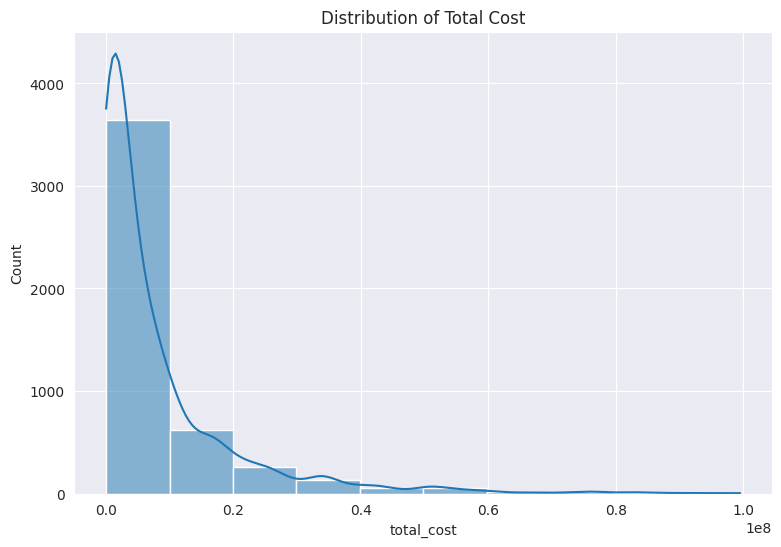

None

np.float64(2.9678480498552684)

In [18]:
# Target variable distribution
sns.set_style('darkgrid')
plt.figure(figsize=(9, 6))
sns.histplot(train['total_cost'], kde=True, bins=10)
plt.title('Distribution of Total Cost')
display(plt.show(), train.total_cost.skew())

The target variable is skewed to the right (Positive skew) with a a degree of ~ 3.
- The right tail is longer, meaning more values are concentrated on the left.
- Most values are lower, but a few high values (outliers) pull the mean to the right.
- The mean > median > mode
- Because the variable is right skewed, it can be handled by <i>Log Transformation</i>

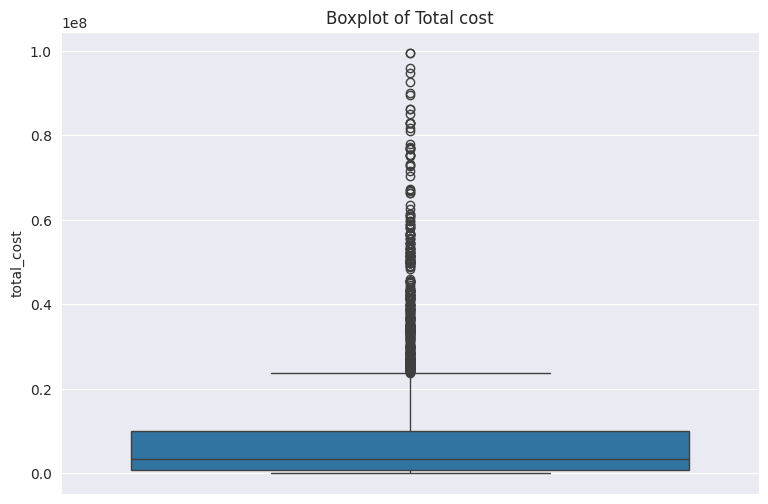

In [19]:
# Plotting outliers in the target variable
sns.set_style('darkgrid')
plt.figure(figsize=(9, 6))
sns.boxplot(train.total_cost)
plt.title('Boxplot of Total cost')
plt.show()

In [20]:
# Correlation between numerical variables and target variable
numeric_corr = train.select_dtypes(include=['number']).corr()['total_cost'].sort_values(ascending = False).head(10)
numeric_corr

,total_cost
total_cost,1.000000
group_size,0.278266
total_nights,0.076723


The numerical features exhibit a weak positive correlation with the target variable.


<----- region ----->
                       mean     median  count
region                                       
Oceania        1.455909e+07  9377996.5    204
North America  1.281142e+07  7508475.0    815
Europe         9.348245e+06  5673325.0   2060
Other          7.910649e+06  8287500.0      5
South America  7.799249e+06  5304000.0     17

<----- age_group ----->
                   mean      median  count
age_group                                 
65+        1.721195e+07  12845625.0    307
45-64      1.105093e+07   5834400.0   1391
25-44      6.026176e+06   2486250.0   2487
1-24       5.415205e+06   2602275.0    624

<----- travel_with ----->
                             mean      median  count
travel_with                                         
Spouse and Children  1.833085e+07  14720606.0    368
Spouse               1.268289e+07   8623454.0   1005
Friends/Relatives    1.023318e+07   4972500.0    895
Children             1.020680e+07   5687662.5    162
Alone                3.66449

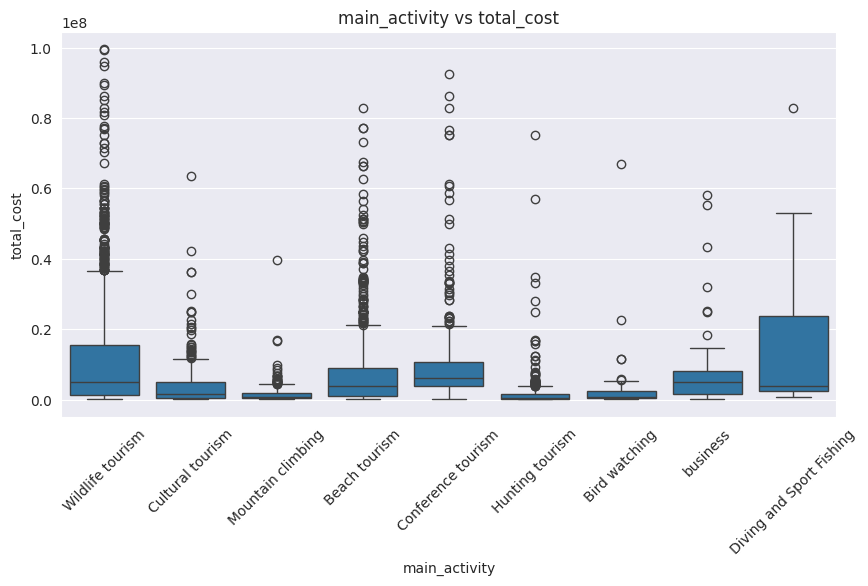

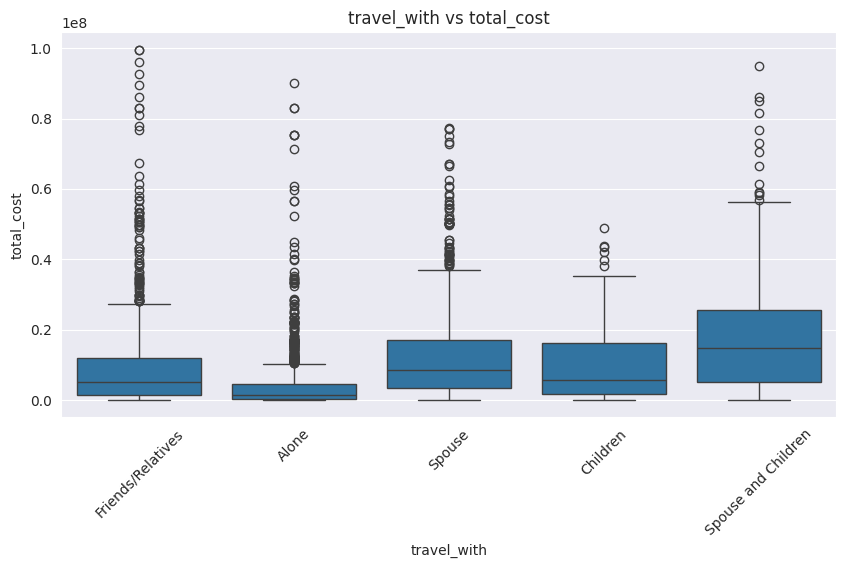

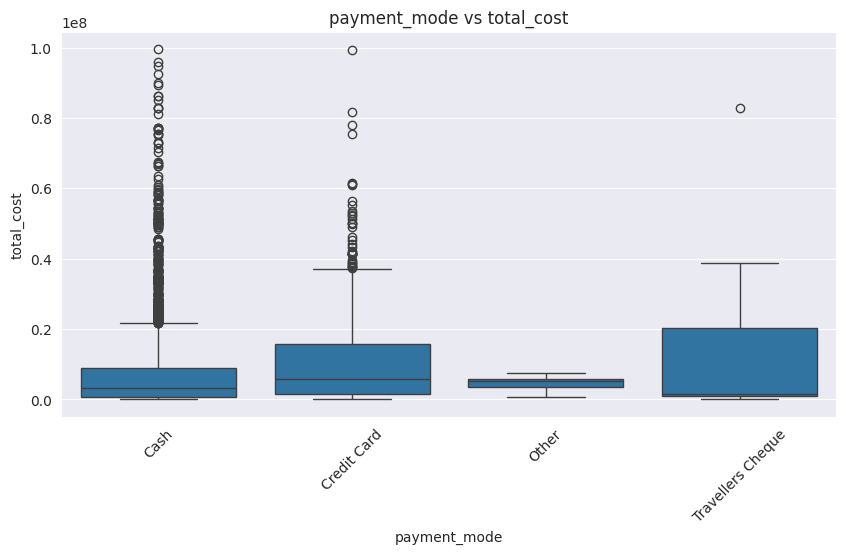

In [21]:
from scipy.stats import f_oneway

# categorical columns
cat_cols = [
    'region', 'age_group', 'travel_with', 'purpose', 'main_activity', 'info_source',
    'tour_arrangement', 'package_transport_int', 'package_accomodation',
    'package_food', 'package_transport_tz', 'package_sightseeing',
    'package_guided_tour', 'package_insurance', 'payment_mode',
    'first_trip_tz', 'most_impressing'
]

target = 'total_cost'

# mean and median analysis
summary = []

for col in cat_cols:
    grouped = train.groupby(col)[target].agg(['mean', 'median', 'count']).sort_values(by='mean', ascending=False)

    print(f"\n<----- {col} ----->")
    print(grouped.head(5))

    # store variation
    variation = grouped['mean'].max() - grouped['mean'].min()

    summary.append({'feature': col, 'mean_variation': variation})

# Convert to DataFrame
train_impacted = pd.DataFrame(summary).sort_values(by='mean_variation', ascending=False)

print("\n\n<--- Feature importance based on Mean Variation) --->")
print(train_impacted)

# Anova test
anova_results = []

for col in cat_cols:
    groups = [group[target].values for name, group in train.groupby(col)]

    if len(groups) > 1:
        f_stat, p_value = f_oneway(*groups)

        anova_results.append({
            'feature': col,
            'F_stat': f_stat,
            'p_value': p_value
        })

anova_train = pd.DataFrame(anova_results).sort_values(by='p_value')

print("\n\n<--- ANOVA Results --->")
print(anova_train)

# Vizualization of top 3 features

top3 = train_impacted.head(3)['feature']

for col in top3:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=col, y=target, data=train)
    plt.title(f"{col} vs {target}")
    plt.xticks(rotation=45)
    plt.show()

ANOVA analysis revealed that all categorical features significantly influence the target variable (total_cost), as all p-values were below 0.05. Package-related features such as accommodation, transport, and food exhibited the strongest impact, indicating that bundled services are key drivers of tourism expenditure.

### Handling Outliers in numerical columns

In [22]:
numeric_colmn = train.select_dtypes(include=[np.number])

Q1 = numeric_colmn.quantile(0.25)
Q3 = numeric_colmn.quantile(0.75)
IQR = Q3 - Q1

train = train[~((numeric_colmn < (Q1 - 1.5 * IQR)) | (numeric_colmn > (Q3 + 1.5 * IQR))).any(axis=1)]

# Train-validation split

In [23]:
from sklearn.model_selection import train_test_split

X = train.drop('total_cost', axis=1)
y  = np.log1p(train['total_cost']) # applying log transformation for right skewness

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

### Encoding

In [24]:
# Binary Encoding
binary_columns = ['package_transport_int', 'package_accomodation', 'package_food', 'package_transport_tz', 'package_sightseeing',
 'package_guided_tour', 'package_insurance', 'first_trip_tz']

for col in binary_columns:
    X_train[col] = X_train[col].map({'Yes': 1, 'No': 0})
    X_val[col] = X_val[col].map({'Yes': 1, 'No': 0})

In [25]:
# One-hot Encoding
onehot_columns = ['age_group', 'most_impressing']

X_train = pd.get_dummies(X_train, columns=onehot_columns, drop_first=True)
X_val = pd.get_dummies(X_val, columns=onehot_columns, drop_first=True)

In [26]:
# Target Encoding
target_cols = ['travel_with', 'purpose', 'main_activity', 'info_source', 'region', 'payment_mode', 'tour_arrangement']

train_temp = X_train.copy()
train_temp['target'] = y_train

for col in target_cols:
    means = train_temp.groupby(col)['target'].mean()

    X_train[col] = X_train[col].map(means)
    X_val[col] = X_val[col].map(means)

# Modeling & Evaluation

## RandomForestRegressor

In [27]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_val)
rf_rmse = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(rf_pred)))
rf_r2score = r2_score(np.expm1(y_val), np.expm1(rf_pred))

print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2 Score:", rf_r2score)

Random Forest RMSE: 4122038.3564942246
Random Forest R2 Score: 0.39364501708738553


## DecisionTreeRegressor

In [28]:
from sklearn.tree import DecisionTreeRegressor
dtr = DecisionTreeRegressor(random_state=42)
dtr.fit(X_train, y_train)

dtr_pred = dtr.predict(X_val)
dtr_rmse = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(dtr_pred)))
dtr_r2score = r2_score(np.expm1(y_val), np.expm1(dtr_pred))

print("Decision Tree RMSE:", dtr_rmse)
print("Decision Tree R2 Score:", dtr_r2score)

Decision Tree RMSE: 5245529.485028471
Decision Tree R2 Score: 0.018067671708839383


## XGBRegressor

In [29]:
from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_val)
xgb_rmse = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(xgb_pred)))
xgb_r2score = r2_score(np.expm1(y_val), np.expm1(xgb_pred))

print("XGBoost RMSE:", xgb_rmse)
print("XGBoost R2 Score:", xgb_r2score)

XGBoost RMSE: 4058460.886584223
XGBoost R2 Score: 0.41220535775817657


XGBoost achieved the best performance, with the lowest RMSE and highest R² score, demonstrating its ability to capture complex nonlinear relationships. Random Forest showed moderate performance, while the Decision Tree model performed poorly. Further improvements can be made to the XGBoost model, after which the test set can be used for prediction.